In [1]:
!pip install vaderSentiment

<h5><Estimate whether negative Airbnb reviews reflect mismatch or quality deficiency. ><h5>

This script treats listing-level scores as *context* rather than per-review labels.
It combines:
1. negative text detection via VADER,
2. rule-based aspect tagging,
3. listing-level quality proxies,
4. recurrence of similar complaints within the same listing.

Outputs are designed to support a report:
- per-review labels: mismatch / deficiency / mixed / unclear
- summary tables
- example reviews for each label

In [2]:
from __future__ import annotations

import argparse
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter


In [3]:
files = ["/Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/listings.csv", "/Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/notes.csv", "/Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/reviews.csv", "/Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/scores.csv"]

for file in files:
    print("\n" + "="*60)
    print(f"FILE: {file}")
    
    df = pd.read_csv(file, low_memory=False)
    
    print("\nColumns:")
    print(df.columns.tolist())
    
    print("\nFirst 3 rows:")
    display(df.head(3))



FILE: /Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/listings.csv

Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32



FILE: /Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/notes.csv

Columns:
['listing_id', 'id_x', 'date', 'reviewer_id', 'reviewer_name', 'comments', 'text', 'id_y', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maxim

,listing_id,id_x,date,reviewer_id,reviewer_name,comments,text,id_y,listing_url,scrape_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,len_text
0,13913,80770,2010-08-18,177109,Michael,My girlfriend and I hadn't known Alina before ...,girlfriend hadnt known Alina took leap faith r...,13913,https://www.airbnb.com/rooms/13913,20250914034649,...,4.78,4.78,NaN,f,2,1,1,0,0.3,606
1,13913,367568,2011-07-11,19835707,Mathias,Alina was a really good host. The flat is clea...,Alina really good host flat clean tidy really ...,13913,https://www.airbnb.com/rooms/13913,20250914034649,...,4.78,4.78,NaN,f,2,1,1,0,0.3,125
2,13913,529579,2011-09-13,1110304,Kristin,Alina is an amazing host. She made me feel rig...,Alina amazing host made feel right home like h...,13913,https://www.airbnb.com/rooms/13913,20250914034649,...,4.78,4.78,NaN,f,2,1,1,0,0.3,226



FILE: /Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/reviews.csv

Columns:
['listing_id', 'date']

First 3 rows:


,listing_id,date
0,13913,2010-08-18
1,13913,2011-07-11
2,13913,2011-09-13



FILE: /Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/scores.csv

Columns:
['listing_id', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'review']

First 3 rows:


,listing_id,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,review
0,13913,4.85,4.8,4.8,4.81,4.87,4.78,4.78,4.812857
1,13913,4.85,4.8,4.8,4.81,4.87,4.78,4.78,4.812857
2,13913,4.85,4.8,4.8,4.81,4.87,4.78,4.78,4.812857


In [4]:
!pip install wordcloud

In [5]:
QUALITY_ASPECTS = {
    "cleanliness": [
        "dirty",
        "filthy",
        "dust",
        "dusty",
        "stain",
        "stained",
        "mold",
        "mould",
        "smell",
        "odor",
        "odour",
        "hair",
        "unclean",
        "cleanliness",
        "bugs",
        "bug",
    ],
    "maintenance": [
        "broken",
        "leak",
        "leaking",
        "heater",
        "heating",
        "shower",
        "toilet",
        "wifi",
        "internet",
        "bedbug",
        "bedbugs",
        "malfunction",
        "repair",
        "air conditioning",
        "hot water",
    ],
    "host_service": [
        "rude",
        "unhelpful",
        "unresponsive",
        "late",
        "cancel",
        "canceled",
        "cancelled",
        "host never replied",
        "host did not reply",
        "communication",
        "check in",
        "check-in",
        "keys",
    ],
    "accuracy_safety": [
        "misleading",
        "not as described",
        "different from photos",
        "different than photos",
        "unsafe",
        "dangerous",
        "lock",
        "scam",
        "fraud",
        "inaccurate",
        "accuracy",
    ],
}

In [6]:
MISMATCH_ASPECTS = {
    "location_fit": [
        "far",
        "distance",
        "commute",
        "tube",
        "transport",
        "location",
        "neighbourhood",
        "neighborhood",
        "area",
        "central",
        "zone",
    ],
    "space_fit": [
        "small",
        "tiny",
        "cramped",
        "stairs",
        "steep",
        "space",
        "layout",
        "narrow",
        "compact",
    ],
    "value_fit": [
        "expensive",
        "overpriced",
        "pricey",
        "value",
        "worth",
        "not worth",
        "too much",
        "cost",
    ],
    "preference_fit": [
        "noisy",
        "noise",
        "loud",
        "firm bed",
        "soft bed",
        "hot",
        "cold",
        "light sleeper",
        "dark",
    ],
}

### Keyword Pattern Dictionary Creation

This block creates a dictionary of keyword-matching patterns for every aspect in the analysis.  

It takes the keyword lists from both **QUALITY_ASPECTS** and **MISMATCH_ASPECTS** and converts each list into a regular expression.  

These patterns are later used to scan each review and detect whether it mentions topics such as:
- cleanliness  
- maintenance  
- location  
- value  
- space  

`\b` ensures that **whole words** are matched rather than parts of larger words.

In [7]:
ALL_PATTERNS = {}

for group in [QUALITY_ASPECTS, MISMATCH_ASPECTS]:
    for key, terms in group.items():
        joined_terms = "|".join(terms)
        pattern_text = r"\b(" + joined_terms + r")\b"
        ALL_PATTERNS[key] = re.compile(pattern_text, re.IGNORECASE)

The purpose is to connect what people say in the review text with the most relevant structured score from the listing. This helps decide whether a complaint looks more like a real listing problem or a mismatch between guest expectations and the listing’s usual profile.

In [8]:
QUALITY_SCORE_MAP = {
    "cleanliness": "review_scores_cleanliness",
    "host_service": "review_scores_communication",
    "accuracy_safety": "review_scores_accuracy",
    "location_fit": "review_scores_location",
    "value_fit": "review_scores_value",
}

In [9]:
input_notes_path = Path("/Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/notes.csv")  
output_dir = Path("airbnb_mismatch_outputs")

negative_threshold = -0.05
high_quality_threshold = 4.7
low_quality_threshold = 4.4
recurrence_threshold = 0.15
examples_per_label = 20
model_confidence_threshold = 0.70


I made to different function since it will be less computing expensive if we verify the % in the 
host_response_rate column and to verify in the price_num the $ and not to verify all this three in both column which will make the model more costly

In [10]:
def parse_percent(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce")

In [11]:
def parse_price(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce")

In [12]:
def prepare_data(path: Path) -> pd.DataFrame:
    usecols = [
        "listing_id",
        "reviewer_id",
        "comments",
        "text",
        "room_type",
        "price",
        "host_response_rate",
        "host_is_superhost",
        "instant_bookable",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ]
    df = pd.read_csv(path, usecols=usecols, low_memory=False)
    text_col = "comments" if "comments" in df.columns else "text"
    df["review_text"] = (
        df[text_col]
        .fillna(df.get("text", ""))
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    df = df[df["review_text"].ne("")].copy()

    numeric_cols = [
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["host_response_rate_num"] = parse_percent(df["host_response_rate"])
    df["price_num"] = parse_price(df["price"])
    df["host_is_superhost_num"] = df["host_is_superhost"].map({"t": 1, "f": 0})
    df["instant_bookable_num"] = df["instant_bookable"].map({"t": 1, "f": 0})

    return df


we create a VADER sentiment tool

In [13]:
def score_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    analyzer = SentimentIntensityAnalyzer()
    df = df.copy()
    df["vader_compound"] = df["review_text"].map(lambda text: analyzer.polarity_scores(text)["compound"])
    return df

For each aspect and its keyword pattern, we will check if each review is having a value as cleanliness, location, or host service, then it creates columns like tag_cleanliness or tag_location_fit, where 1 means the aspect is mentioned and 0 means it is not

In [14]:
def tag_aspects(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    lowered = df["review_text"].str.lower()
    for name, pattern in ALL_PATTERNS.items():
        df[f"tag_{name}"] = lowered.str.contains(pattern, na=False).astype(int)
    return df

We took the columns from the first code box, then we group, average and  rename them with listing_... , then we did the same but with negative mask and we did this to all the columns starting with tag_... and we trasnformed it in recurrence_ columns 
Shortly what We did We averaged quality/host features for each listing and how often different problem tags show up in that listing’s negative reviews.

In [15]:
def build_listing_context(df: pd.DataFrame) -> pd.DataFrame:
    quality_cols = [
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ]

    listing_quality = (
        df.groupby("listing_id")[quality_cols + ["host_response_rate_num", "host_is_superhost_num", "instant_bookable_num"]]
        .mean(numeric_only=True)
        .rename(columns=lambda col: f"listing_{col}")
    )

    negative_mask = df["vader_compound"] <= -0.05
    recurrence = (
        df.loc[negative_mask]
        .groupby("listing_id")[[c for c in df.columns if c.startswith("tag_")]]
        .mean()
        .rename(columns=lambda col: f"recurrence_{col[4:]}")
    )

    return listing_quality.join(recurrence, how="left").fillna(0)

In this code blox with df.join we make teh review to have both review fields like vader_compound, tag_cleanliness, etc.
and listing-level fields like listing_review_scores_cleanliness, recurrence_cleanliness etc.
Afterwards we  created lists of quality-related tags and mismatch-related tags, then counted how many of each type appear in every review. After that, we calculated the average overall quality of each listing from its review score columns. Then, using iterrows(), we went through each review one by one and built two scores: a deficiency_score, which increases when the review mentions real quality problems that are also supported by low listing scores or repeated negative complaints, and a mismatch_score, which increases when the complaint seems more related to guest expectations even though the listing is generally well rated.

In [16]:
def classify_reviews(
    df: pd.DataFrame,
    listing_context: pd.DataFrame,
    high_quality_threshold: float,
    low_quality_threshold: float,
    recurrence_threshold: float,
    negative_threshold: float,
) -> pd.DataFrame:
    df = df.join(listing_context, on="listing_id")
    df["is_negative_review"] = df["vader_compound"] <= negative_threshold

    quality_tag_cols = [f"tag_{name}" for name in QUALITY_ASPECTS]
    mismatch_tag_cols = [f"tag_{name}" for name in MISMATCH_ASPECTS]

    df["quality_tag_count"] = df[quality_tag_cols].sum(axis=1)
    df["mismatch_tag_count"] = df[mismatch_tag_cols].sum(axis=1)

    df["listing_quality_mean"] = df[
        [
            "listing_review_scores_rating",
            "listing_review_scores_accuracy",
            "listing_review_scores_cleanliness",
            "listing_review_scores_communication",
            "listing_review_scores_location",
            "listing_review_scores_value",
        ]
    ].mean(axis=1)

    deficiency_scores = []
    mismatch_scores = []

    for _, row in df.iterrows():
        deficiency_score = float(row["quality_tag_count"])
        mismatch_score = float(row["mismatch_tag_count"])

        for aspect, score_col in QUALITY_SCORE_MAP.items():
            tag_col = f"tag_{aspect}"
            listing_score_col = f"listing_{score_col}"
            recurrence_col = f"recurrence_{aspect}"

            if row.get(tag_col, 0) == 1:
                listing_score = row.get(listing_score_col, np.nan)
                recurrence = row.get(recurrence_col, 0.0)

                if pd.notna(listing_score) and listing_score <= low_quality_threshold:
                    deficiency_score += 1.5
                if recurrence >= recurrence_threshold:
                    deficiency_score += 1.0

        if row.get("tag_location_fit", 0) == 1 and row.get("listing_review_scores_location", np.nan) >= high_quality_threshold:
            mismatch_score += 1.5
        if row.get("tag_value_fit", 0) == 1 and row.get("listing_review_scores_value", np.nan) >= high_quality_threshold:
            mismatch_score += 1.5
        if row.get("tag_space_fit", 0) == 1 and row.get("listing_quality_mean", np.nan) >= high_quality_threshold:
            mismatch_score += 1.0
        if row.get("tag_preference_fit", 0) == 1 and row.get("listing_quality_mean", np.nan) >= high_quality_threshold:
            mismatch_score += 1.0
        if row.get("listing_quality_mean", np.nan) >= high_quality_threshold and row["quality_tag_count"] == 0 and row["mismatch_tag_count"] > 0:
            mismatch_score += 1.0
        if row.get("listing_quality_mean", np.nan) <= low_quality_threshold and row["quality_tag_count"] > 0:
            deficiency_score += 1.0

        deficiency_scores.append(deficiency_score)
        mismatch_scores.append(mismatch_score)

    df["deficiency_score"] = deficiency_scores
    df["mismatch_score"] = mismatch_scores

    def assign_label(row: pd.Series) -> str:
        if not row["is_negative_review"]:
            return "not_negative"
        if row["deficiency_score"] >= row["mismatch_score"] + 1:
            return "deficiency"
        if row["mismatch_score"] >= row["deficiency_score"] + 1:
            return "mismatch"
        if row["deficiency_score"] > 0 and row["mismatch_score"] > 0:
            return "mixed"
        return "unclear"

    df["review_label"] = df.apply(assign_label, axis=1)
    return df


We trained a vectoriser and a logistic regression
Furthermore, we trained a text model on negative reviews already labeled as mismatch or deficiency, tested its performance, and then used it to relabel some of the unclear reviews when the prediction confidence was high enough. Finally, I saved the new labels, confidence scores, and summary metrics back into the dataset.

In [17]:
def expand_unclear_with_text_model(
    df: pd.DataFrame,
    confidence_threshold: float,
) -> tuple[pd.DataFrame, dict]:
    df = df.copy()
    negative_df = df[df["is_negative_review"]].copy()

    train_df = negative_df[negative_df["review_label"].isin(["mismatch", "deficiency"])].copy()
    unclear_df = negative_df[negative_df["review_label"].eq("unclear")].copy()

    metrics: dict[str, float | int | str] = {
        "train_rows": int(len(train_df)),
        "unclear_rows": int(len(unclear_df)),
    }

    if len(train_df) < 200 or train_df["review_label"].nunique() < 2 or unclear_df.empty:
        df["review_label_expanded"] = df["review_label"]
        metrics["model_used"] = "no"
        return df, metrics

    X_train_text, X_test_text, y_train, y_test = train_test_split(
        train_df["review_text"],
        train_df["review_label"],
        test_size=0.2,
        random_state=42,
        stratify=train_df["review_label"],
    )

    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=5)
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)

    metrics["model_used"] = "yes"# quick check
    metrics["holdout_accuracy"] = round(float(accuracy_score(y_test, test_pred)), 4)
    metrics["holdout_report"] = classification_report(y_test, test_pred, digits=4)

    unclear_X = vectorizer.transform(unclear_df["review_text"])
    unclear_probs = model.predict_proba(unclear_X)
    unclear_pred = model.classes_[unclear_probs.argmax(axis=1)]
    unclear_conf = unclear_probs.max(axis=1)

    confident_mask = unclear_conf >= confidence_threshold
    unclear_df["model_label"] = np.where(confident_mask, unclear_pred, "unclear")
    unclear_df["model_confidence"] = unclear_conf

    df["review_label_expanded"] = df["review_label"]
    df["model_confidence"] = np.nan
    df.loc[unclear_df.index, "model_confidence"] = unclear_df["model_confidence"]
    df.loc[unclear_df.index, "review_label_expanded"] = unclear_df["model_label"]

    metrics["relabeled_unclear_rows"] = int(confident_mask.sum())
    metrics["relabeled_unclear_share_pct"] = round(float(confident_mask.mean() * 100), 2)
    return df, metrics


We first created the output folder so the result files could be saved correctly. Then I kept only the negative reviews and selected the appropriate label column depending on whether expanded labels were available. After that, I built summary tables for the original labels, the expanded labels, the distribution of labels by room type, and the average tag frequencies by label. I also selected a few example reviews for each label, focusing on the strongest cases. Finally, I saved all these outputs as CSV files and wrote two JSON files: one with the main headline statistics and one with the text model metrics.

In [18]:
def write_outputs(
    df: pd.DataFrame,
    output_dir: Path,
    examples_per_label: int,
    model_metrics: dict,
) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)

    negative_df = df[df["is_negative_review"]].copy()
    negative_expanded = negative_df.copy()
    label_col = "review_label_expanded" if "review_label_expanded" in negative_expanded.columns else "review_label"

    label_summary = (
        negative_df["review_label"]
        .value_counts(dropna=False)
        .rename_axis("review_label")
        .reset_index(name="count")
    )
    label_summary["share_pct"] = (label_summary["count"] / len(negative_df) * 100).round(2)

    expanded_summary = (
        negative_expanded[label_col]
        .value_counts(dropna=False)
        .rename_axis("review_label")
        .reset_index(name="count")
    )
    expanded_summary["share_pct"] = (expanded_summary["count"] / len(negative_expanded) * 100).round(2)

    room_type_summary = (
        negative_expanded.groupby(["room_type", label_col])
        .size()
        .rename("count")
        .reset_index()
    )
    room_type_summary = room_type_summary.rename(columns={label_col: "review_label"})

    examples = (
        negative_expanded.sort_values([label_col, "mismatch_score", "deficiency_score"], ascending=[True, False, False])
        .groupby(label_col)
        .head(examples_per_label)
        [
            [
                "listing_id",
                "reviewer_id",
                "room_type",
                "price_num",
                "listing_quality_mean",
                "vader_compound",
                "review_label",
                "review_label_expanded",
                "mismatch_score",
                "deficiency_score",
                "review_text",
            ]
        ]
    )

    aspect_cols = [c for c in negative_df.columns if c.startswith("tag_")]
    aspect_summary = (
        negative_expanded.groupby(label_col)[aspect_cols]
        .mean()
        .mul(100)
        .round(2)
        .reset_index()
    )
    aspect_summary = aspect_summary.rename(columns={label_col: "review_label"})

    negative_df.to_csv(output_dir / "review_level_labels.csv", index=False)
    label_summary.to_csv(output_dir / "label_summary.csv", index=False)
    expanded_summary.to_csv(output_dir / "expanded_label_summary.csv", index=False)
    room_type_summary.to_csv(output_dir / "label_by_room_type.csv", index=False)
    aspect_summary.to_csv(output_dir / "aspect_summary_by_label.csv", index=False)
    examples.to_csv(output_dir / "example_reviews_by_label.csv", index=False)

    headline = {
        "negative_reviews_analyzed": int(len(negative_df)),
        "mismatch_share_pct": round(float(label_summary.loc[label_summary["review_label"].eq("mismatch"), "share_pct"].sum()), 2),
        "deficiency_share_pct": round(float(label_summary.loc[label_summary["review_label"].eq("deficiency"), "share_pct"].sum()), 2),
        "mixed_share_pct": round(float(label_summary.loc[label_summary["review_label"].eq("mixed"), "share_pct"].sum()), 2),
        "unclear_share_pct": round(float(label_summary.loc[label_summary["review_label"].eq("unclear"), "share_pct"].sum()), 2),
        "expanded_mismatch_share_pct": round(float(expanded_summary.loc[expanded_summary["review_label"].eq("mismatch"), "share_pct"].sum()), 2),
        "expanded_deficiency_share_pct": round(float(expanded_summary.loc[expanded_summary["review_label"].eq("deficiency"), "share_pct"].sum()), 2),
        "expanded_mixed_share_pct": round(float(expanded_summary.loc[expanded_summary["review_label"].eq("mixed"), "share_pct"].sum()), 2),
        "expanded_unclear_share_pct": round(float(expanded_summary.loc[expanded_summary["review_label"].eq("unclear"), "share_pct"].sum()), 2),
    }
    (output_dir / "headline_summary.json").write_text(json.dumps(headline, indent=2), encoding="utf-8")
    (output_dir / "text_model_metrics.json").write_text(json.dumps(model_metrics, indent=2), encoding="utf-8")

 We read the command-line arguments, then we prepared the data, calculated sentiment scores, and tagged the main aspects mentioned in the reviews. After that, we built listing-level context, used it to classify reviews with the rule-based method, and then applied the text model to relabel some of the unclear reviews. Finally, we saved all outputs, printed the percentage distribution of the original and expanded negative-review labels, showed where the files were saved, and returned 0 to indicate that the program finished successfully.

In [19]:
df = prepare_data(input_notes_path)
df = score_sentiment(df)
df = tag_aspects(df)

listing_context = build_listing_context(df)

labeled = classify_reviews(
    df,
    listing_context,
    high_quality_threshold=high_quality_threshold,
    low_quality_threshold=low_quality_threshold,
    recurrence_threshold=recurrence_threshold,
    negative_threshold=negative_threshold,
)
print(type(labeled))
expanded, model_metrics = expand_unclear_with_text_model(
    labeled,
    confidence_threshold=model_confidence_threshold,
)

write_outputs(expanded, output_dir, examples_per_label, model_metrics)

negative_only = expanded[expanded["is_negative_review"]]
summary = negative_only["review_label"].value_counts(normalize=True).mul(100).round(2)
expanded_summary = negative_only["review_label_expanded"].value_counts(normalize=True).mul(100).round(2)

print("Rule-based negative-review label distribution (%):")
print(summary.to_string())

print("\nExpanded negative-review label distribution (%):")
print(expanded_summary.to_string())

print(f"\nOutputs written to: {output_dir}")


/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_85657/1789785927.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"tag_{name}"] = lowered.str.contains(pattern, na=False).astype(int)
/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_85657/1789785927.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"tag_{name}"] = lowered.str.contains(pattern, na=False).astype(int)
/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_85657/1789785927.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[f"tag_{name}"] = lowered.str.contains(pattern, na=False).astype(int)
/var/folders/z9/yljky7zj70z5lp2gz0k3bdq00000gn/T/ipykernel_85657/1789785927.py:5: UserWarning: This pattern is interpreted as a regul

<class 'pandas.core.frame.DataFrame'>
Rule-based negative-review label distribution (%):
review_label
unclear       77.64
deficiency    10.32
mismatch       9.21
mixed          2.83

Expanded negative-review label distribution (%):
review_label_expanded
unclear       66.94
deficiency    20.94
mismatch       9.29
mixed          2.83

Outputs written to: airbnb_mismatch_outputs


What we can conclude the model have a 77.65 unclear labels where it cannot decide, we should modify the parameters, after the expanded version we gathered a smaller unclear label which is good

Deficiency means the negative review is pointing to a real problem in the listing or service.
Mismatch means the review is negative more because the guest’s expectations did not match the listing, even if the listing is generally rated well.

Also after the expanded version nearly only deficency has increased, but still

In [20]:
avg_rating_by_label_rule = (
    negative_only.groupby("review_label")["listing_review_scores_rating"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_rating_by_label_rule)


review_label
unclear       4.75
mismatch      4.74
deficiency    4.63
mixed         4.61
Name: listing_review_scores_rating, dtype: float64


In [21]:
negative_only = expanded[expanded["is_negative_review"]].copy()

avg_rating_by_label = (
    negative_only.groupby("review_label_expanded")["listing_review_scores_rating"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_rating_by_label)


review_label_expanded
unclear       4.75
mismatch      4.74
deficiency    4.68
mixed         4.61
Name: listing_review_scores_rating, dtype: float64


In [22]:
rating_summary = (
    negative_only.groupby("review_label_expanded")["listing_review_scores_rating"]
    .agg(["count", "mean"])
    .round(2)
    .rename(columns={"count": "n_reviews", "mean": "avg_rating"})
)

print(rating_summary)


                       n_reviews  avg_rating
review_label_expanded                       
deficiency                  1035        4.68
mismatch                     459        4.74
mixed                        140        4.61
unclear                     3308        4.75


In [23]:
negative_only = expanded[expanded["is_negative_review"]].copy()

rating_col = "listing_review_scores_rating" if "listing_review_scores_rating" in negative_only.columns else "review_scores_rating"

rating_summary = (
    negative_only.groupby("review_label_expanded")[rating_col]
    .agg(n_reviews="size", avg_rating="mean", median_rating="median", min_rating="min", max_rating="max")
    .round(2)
)

print(rating_summary)


                       n_reviews  avg_rating  median_rating  min_rating  \
review_label_expanded                                                     
deficiency                  1035        4.68           4.70        3.00   
mismatch                     459        4.74           4.77        4.00   
mixed                        140        4.61           4.56        3.67   
unclear                     3308        4.75           4.79        3.63   

                       max_rating  
review_label_expanded              
deficiency                    5.0  
mismatch                      5.0  
mixed                         5.0  
unclear                       5.0  


positive words cloud


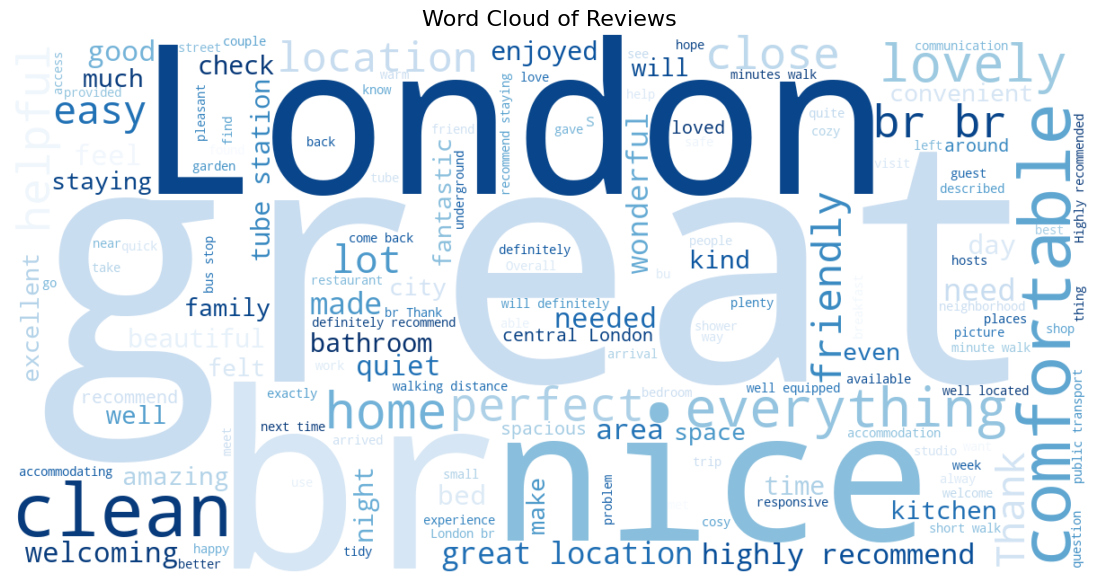

In [24]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt


text = " ".join(df["review_text"].dropna().astype(str))
custom_stopwords = STOPWORDS.union({
    "airbnb", "place", "stay", "stayed", "host", "room", "apartment",
    "flat", "house", "would", "could", "also", "really", "one", "us"
})

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Blues",
    max_words=150
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Reviews", fontsize=16)
plt.show()


negative word cloud

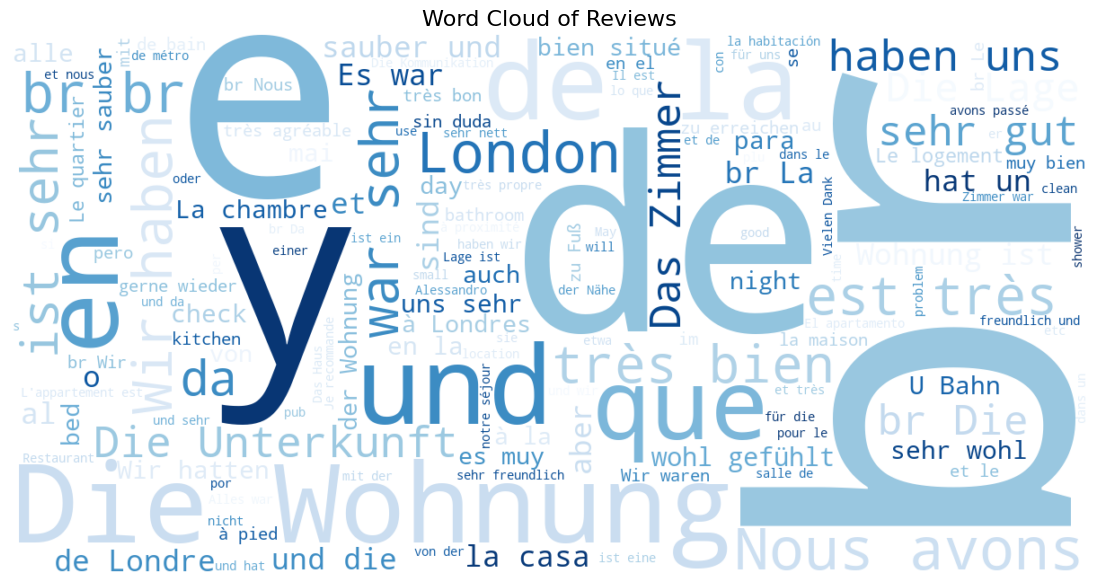

In [25]:
text = " ".join(expanded.loc[expanded["is_negative_review"], "review_text"].dropna().astype(str))

custom_stopwords = STOPWORDS.union({
    "airbnb", "place", "stay", "stayed", "host", "room", "apartment",
    "flat", "house", "would", "could", "also", "really", "one", "us"
})

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Blues",
    max_words=150
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Reviews", fontsize=16)
plt.show()


word cloud postive word more constrained with more stop words

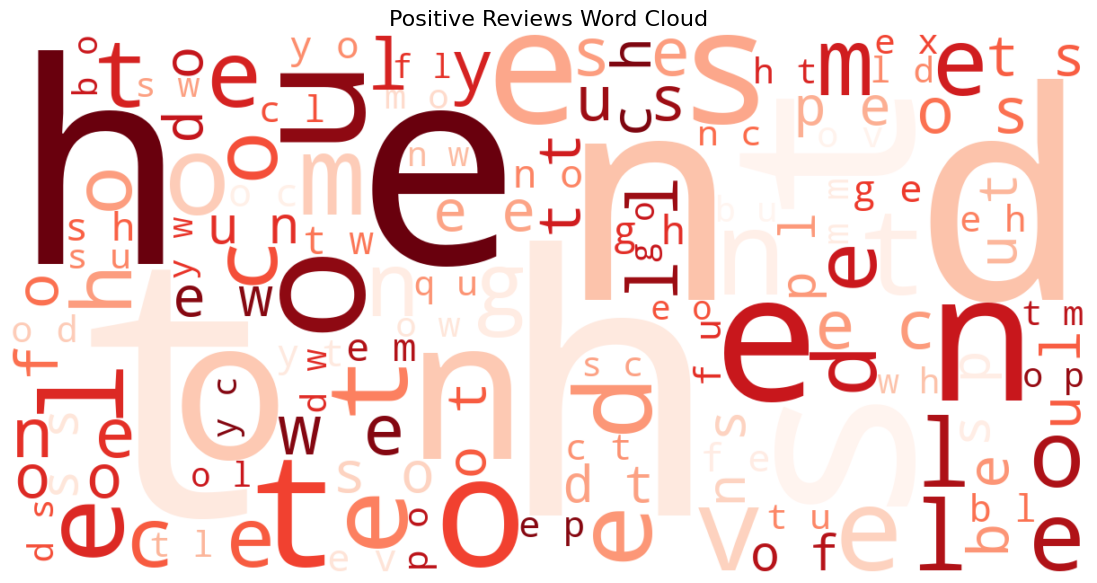

In [26]:

text1 = " ".join(df["review_text"].dropna().astype(str))


clean_text = " ".join(text1)
clean_text = re.sub(r"<br\s*/?>", " ", clean_text)
clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
clean_text = re.sub(r"\s+", " ", clean_text).lower()

stop_words = {
    "the", "and", "for", "that", "with", "was", "were", "this", "have", "had",
    "very", "just", "really", "also", "would", "could", "there", "from", "been",
    "place", "stay", "stayed", "room", "flat", "apartment", "home", "airbnb",
    "great", "nice", "good", "everything", "easy", "close", "thank", "london",
    "friendly", "helpful", "comfortable", "lovely", "perfect", "host",
    "de", "la", "le", "les", "et", "des", "une", "un", "est", "que", "dans",
    "die", "der", "das", "und", "ist", "nicht", "wir", "war", "sehr",
    "el", "en", "es", "los", "las", "una", "muy", "pero", "con",
    "br", "hst", "ck", "fr", "tro", "sm"
}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Reds",
    max_words=100
).generate(clean_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud", fontsize=16)
plt.show()


word cloud negative word more constrained with more stop words


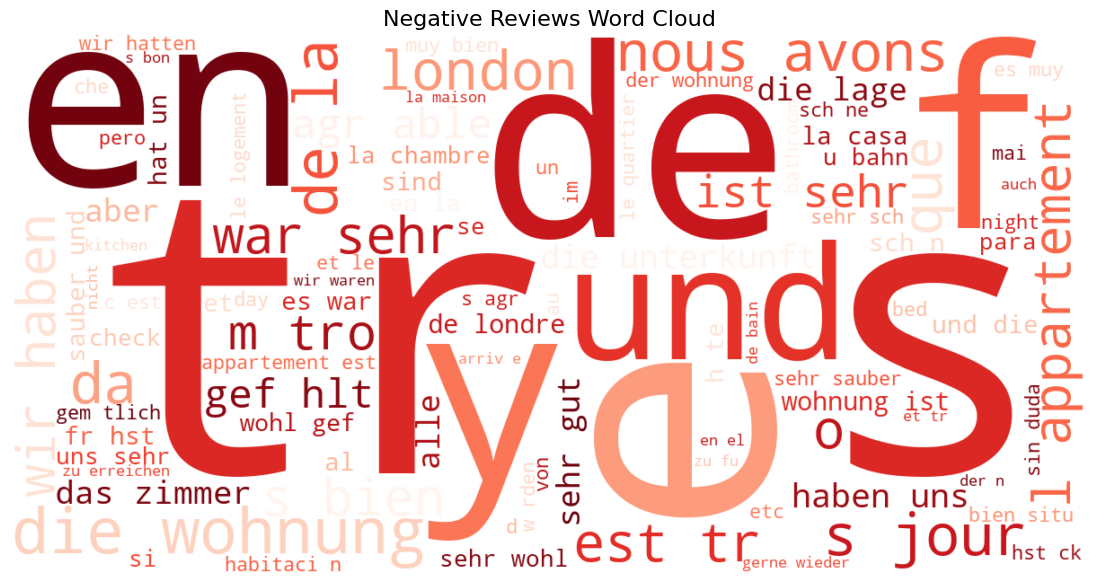

<Figure size 640x480 with 0 Axes>

In [27]:
text_series = expanded.loc[expanded["is_negative_review"], "review_text"].dropna().astype(str)



clean_text = " ".join(text_series)
clean_text = re.sub(r"<br\s*/?>", " ", clean_text)
clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
clean_text = re.sub(r"\s+", " ", clean_text).lower()

stop_words = {
    "the", "and", "for", "that", "with", "was", "were", "this", "have", "had",
    "very", "just", "really", "also", "would", "could", "there", "from", "been",
    "place", "stay", "stayed", "room", "flat", "apartment", "home", "airbnb",
    "great", "nice", "good", "everything", "easy", "close", "thank", "london",
    "friendly", "helpful", "comfortable", "lovely", "perfect", "host",
    "de", "la", "le", "les", "et", "des", "une", "un", "est", "que", "dans",
    "die", "der", "das", "und", "ist", "nicht", "wir", "war", "sehr",
    "el", "en", "es", "los", "las", "una", "muy", "pero", "con",
    "br", "hst", "ck", "fr", "tro", "sm"
}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Reds",
    max_words=100
).generate(clean_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud", fontsize=16)
plt.show()
plt.tight_layout()
plt.savefig("figures/positive_wordcloudd.png", dpi=300, bbox_inches="tight")
plt.show()



word count for postive words


In [28]:
import re
from collections import Counter
import pandas as pd

text_series = expanded.loc[~expanded["is_negative_review"], "review_text"].dropna().astype(str)


clean_text = " ".join(text_series)
clean_text = re.sub(r"<br\s*/?>", " ", clean_text)
clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
clean_text = re.sub(r"\s+", " ", clean_text).lower()

words = clean_text.split()

stop_words = {
    "the", "and", "for", "that", "with", "was", "were", "this", "have", "had",
    "very", "just", "really", "also", "would", "could", "there", "from", "been",
    "place", "stay", "stayed", "room", "flat", "apartment", "home", "airbnb",
    "great", "nice", "good", "everything", "easy", "close", "thank", "london",
    "friendly", "helpful", "comfortable", "lovely", "perfect", "host",
    "de", "la", "le", "les", "et", "des", "une", "un", "est", "que", "dans",
    "die", "der", "das", "und", "ist", "nicht", "wir", "war", "sehr",
    "el", "en", "es", "los", "las", "una", "muy", "pero", "con",
    "br", "hst", "ck", "fr", "tro", "sm"
}

filtered_words = [w for w in words if len(w) > 2 and w not in stop_words]

word_counts = Counter(filtered_words)

top_words = pd.DataFrame(word_counts.most_common(100), columns=["word", "count"])
print(top_words.head(30))


          word  count
0          you  48091
1     location  36815
2        clean  32654
3          our  29668
4    recommend  24603
5          all  23246
6          but  22546
7          are  22522
8         well  21327
9        again  20664
10       house  20246
11        time  18485
12         her  17941
13         she  17047
14     station  16215
15        walk  15742
16        tube  15611
17  definitely  14945
18       quiet  14921
19         not  14137
20        area  13943
21       which  13749
22      highly  12376
23   wonderful  12254
24        will  12172
25         out  11693
26         get  11579
27         has  11429
28        made  11416
29         can  11250


word count for negative words


In [29]:
text_series = expanded.loc[expanded["is_negative_review"], "review_text"].dropna().astype(str)

clean_text = " ".join(text_series)
clean_text = re.sub(r"<br\s*/?>", " ", clean_text)
clean_text = re.sub(r"[^a-zA-Z\s]", " ", clean_text)
clean_text = re.sub(r"\s+", " ", clean_text).lower()

words = clean_text.split()

stop_words = {
    "the", "and", "for", "that", "with", "was", "were", "this", "have", "had",
    "very", "just", "really", "also", "would", "could", "there", "from", "been",
    "place", "stay", "stayed", "room", "flat", "apartment", "home", "airbnb",
    "great", "nice", "good", "everything", "easy", "close", "thank", "london",
    "friendly", "helpful", "comfortable", "lovely", "perfect", "host",
    "de", "la", "le", "les", "et", "des", "une", "un", "est", "que", "dans",
    "die", "der", "das", "und", "ist", "nicht", "wir", "war", "sehr",
    "el", "en", "es", "los", "las", "una", "muy", "pero", "con",
    "br", "hst", "ck", "fr", "tro", "sm"
}

filtered_words = [w for w in words if len(w) > 2 and w not in stop_words]

word_counts = Counter(filtered_words)

top_words = pd.DataFrame(word_counts.most_common(100), columns=["word", "count"])
print(top_words.head(30))


           word  count
0          nous   1816
1           mit   1541
2           uns   1458
3          bien   1369
4           man   1285
5          pour   1252
6       wohnung   1170
7           hat   1113
8           ein   1113
9          tout   1079
10         auch   1029
11         eine   1015
12        haben   1001
13        alles    969
14      londres    922
15  appartement    874
16          not    864
17          gut    863
18          nos    840
19          ich    839
20          den    808
21          bei    805
22         para    788
23          von    785
24   unterkunft    704
25        avons    695
26       zimmer    693
27        waren    685
28          sch    670
29          but    662


Inputs for the tablesm we are going to use in the report

In [30]:
base = Path("/Users/raresolteanu/Downloads/airbnb_mismatch_outputs")
notes_path = Path("/Users/raresolteanu/Downloads/AirBNB/AirBNB_London_Analysis/notes.csv")
out = Path("/Users/raresolteanu/Documents/New project/airbnb_report_assets")
out.mkdir(parents=True, exist_ok=True)

How we are going to save the table in order to attach them in the report

In [31]:
label_summary = pd.read_csv(base / "label_summary.csv")
expanded_summary = pd.read_csv(base / "expanded_label_summary.csv")
room = pd.read_csv(base / "label_by_room_type.csv")
aspect = pd.read_csv(base / "aspect_summary_by_label.csv")
reviews = pd.read_csv(base / "review_level_labels.csv")


Distribution comparison

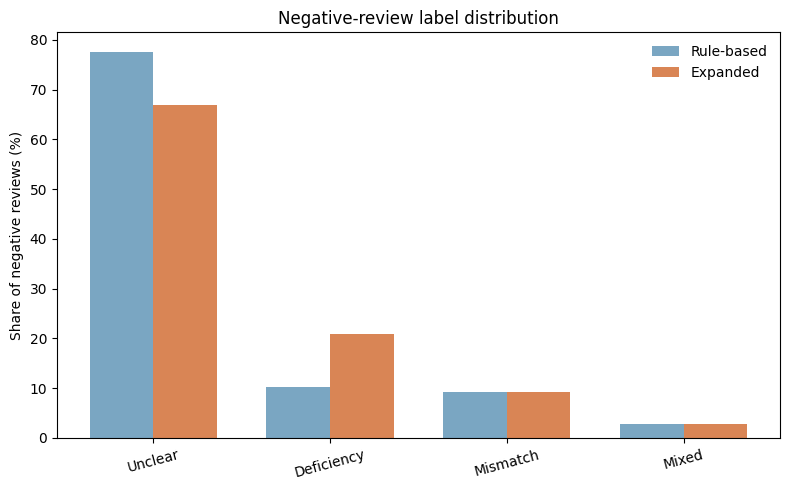

In [32]:
order = ["unclear", "deficiency", "mismatch", "mixed"]

ls = label_summary.set_index("review_label").reindex(order).reset_index()
es = expanded_summary.set_index("review_label").reindex(order).reset_index()

x = np.arange(len(order))
width = 0.36

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, ls["share_pct"], width, label="Rule-based", color="#7aa6c2")
plt.bar(x + width / 2, es["share_pct"], width, label="Expanded", color="#d98555")
plt.xticks(x, [s.replace("_", " ").title() for s in order], rotation=15)
plt.ylabel("Share of negative reviews (%)")
plt.title("Negative-review label distribution")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(out / "label_distribution_comparison.png", dpi=200)
plt.show()
plt.close()

Room type and the labels

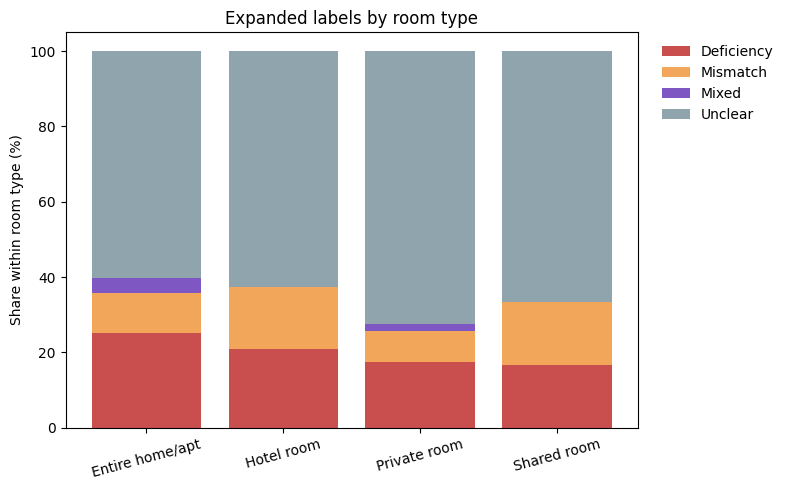

In [33]:
pivot = room.pivot(index="room_type", columns="review_label", values="count").fillna(0)
pivot = pivot[["deficiency", "mismatch", "mixed", "unclear"]]
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

colors = ["#c94f4f", "#f2a65a", "#7e57c2", "#90a4ae"]

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(pct))

for col, color in zip(pct.columns, colors):
    ax.bar(
        pct.index,
        pct[col],
        bottom=bottom,
        label=col.replace("_", " ").title(),
        color=color,
    )
    bottom += pct[col].to_numpy()

ax.set_ylabel("Share within room type (%)")
ax.set_title("Expanded labels by room type")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(out / "room_type_label_mix.png", dpi=200)
plt.show()
plt.close()

Heat Map

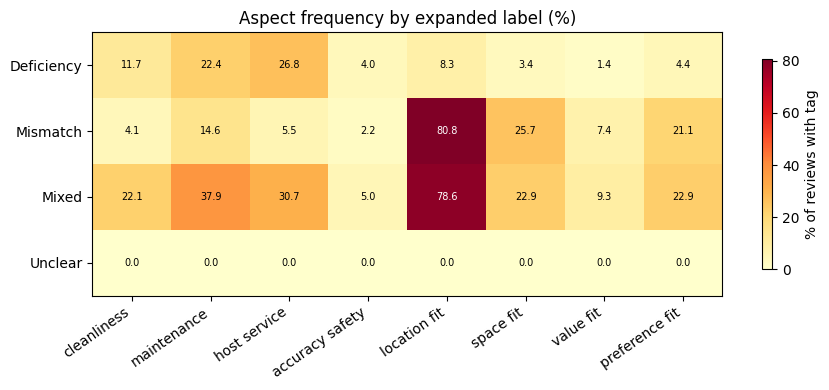

In [34]:
aspect_plot = aspect.set_index("review_label")
cols = [c for c in aspect_plot.columns if c.startswith("tag_")]
aspect_plot = aspect_plot[cols]
aspect_plot.columns = [c.replace("tag_", "").replace("_", " ") for c in aspect_plot.columns]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(aspect_plot.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(aspect_plot.columns)))
ax.set_xticklabels(aspect_plot.columns, rotation=35, ha="right")
ax.set_yticks(range(len(aspect_plot.index)))
ax.set_yticklabels([i.title() for i in aspect_plot.index])
ax.set_title("Aspect frequency by expanded label (%)")

for i in range(aspect_plot.shape[0]):
    for j in range(aspect_plot.shape[1]):
        v = aspect_plot.iloc[i, j]
        ax.text(
            j,
            i,
            f"{v:.1f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black" if v < 60 else "white",
        )

fig.colorbar(im, ax=ax, shrink=0.8, label="% of reviews with tag")
plt.tight_layout()
plt.savefig(out / "aspect_heatmap.png", dpi=200)
plt.show()
plt.close()

Average listing rating by label 

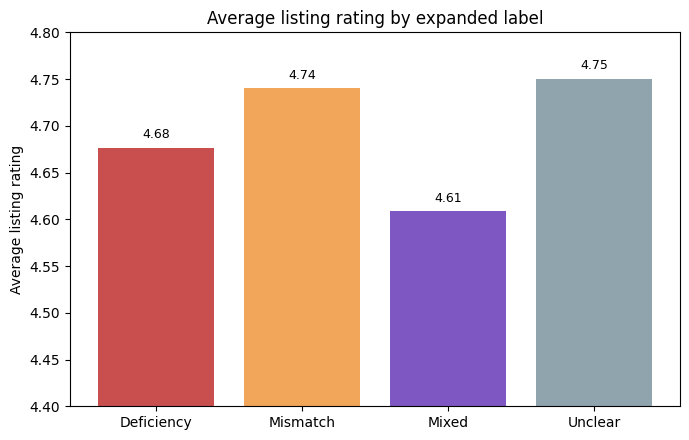

In [35]:
rating_summary = (
    reviews.groupby("review_label_expanded")["listing_review_scores_rating"]
    .agg(n_reviews="size", avg_rating="mean")
    .reindex(["deficiency", "mismatch", "mixed", "unclear"])
)

plt.figure(figsize=(7, 4.5))
plt.bar(
    rating_summary.index.str.title(),
    rating_summary["avg_rating"],
    color=["#c94f4f", "#f2a65a", "#7e57c2", "#90a4ae"],
)
plt.ylabel("Average listing rating")
plt.ylim(4.4, 4.8)
plt.title("Average listing rating by expanded label")

for i, v in enumerate(rating_summary["avg_rating"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(out / "avg_listing_rating_by_label.png", dpi=200)
plt.show()
plt.close()

top words for both positive and negative reviews

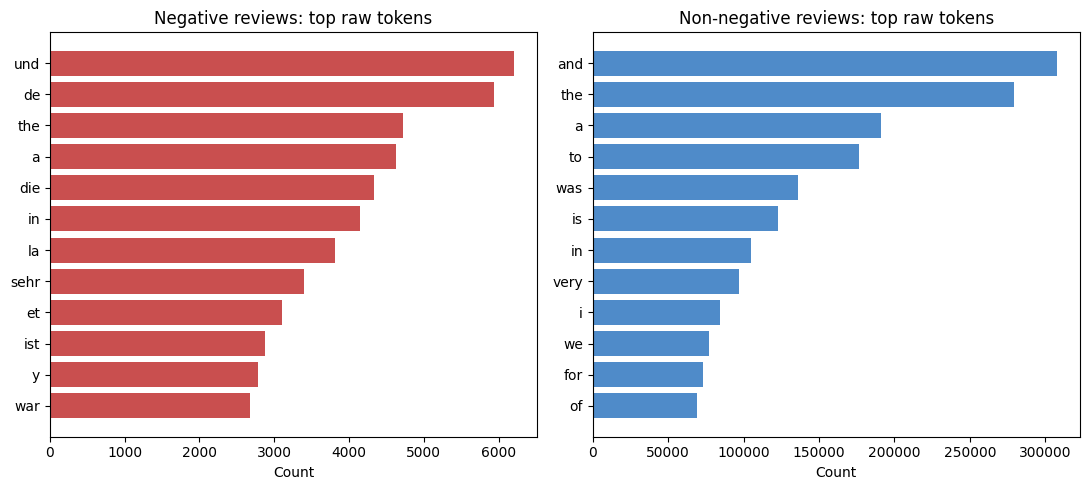

In [36]:
notes = pd.read_csv(notes_path, usecols=["comments", "text"], low_memory=False)
text_col = "comments" if "comments" in notes.columns else "text"

notes["review_text"] = (
    notes[text_col]
    .fillna(notes.get("text", ""))
    .fillna("")
    .astype(str)
)

notes = notes[notes["review_text"].str.strip().ne("")].copy()

analyzer = SentimentIntensityAnalyzer()
notes["vader_compound"] = notes["review_text"].map(
    lambda t: analyzer.polarity_scores(t)["compound"]
)

neg = notes.loc[notes["vader_compound"] <= -0.05, "review_text"]
pos = notes.loc[notes["vader_compound"] > -0.05, "review_text"]

def counts(series):
    text = " ".join(series.dropna().astype(str))
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ]", " ", text)
    text = re.sub(r"\s+", " ", text).lower()
    return Counter(text.split())

neg_counts = counts(neg)
pos_counts = counts(pos)

neg_top = pd.DataFrame(neg_counts.most_common(12), columns=["word", "count"])
pos_top = pd.DataFrame(pos_counts.most_common(12), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].barh(neg_top["word"][::-1], neg_top["count"][::-1], color="#c94f4f")
axes[0].set_title("Negative reviews: top raw tokens")
axes[0].set_xlabel("Count")

axes[1].barh(pos_top["word"][::-1], pos_top["count"][::-1], color="#4f8bc9")
axes[1].set_title("Non-negative reviews: top raw tokens")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig(out / "raw_top_words_positive_negative.png", dpi=200)
plt.show()
plt.close()

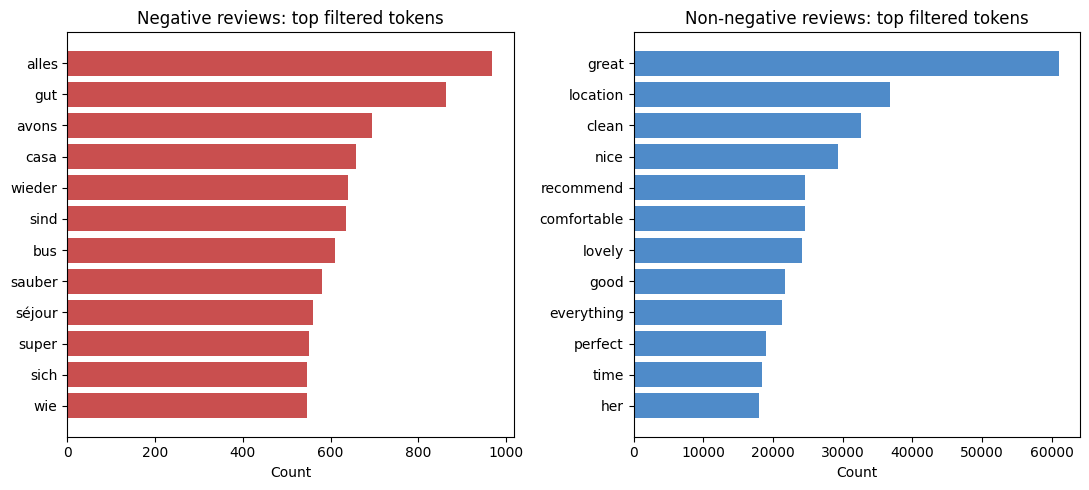

In [37]:
notes = pd.read_csv(notes_path, usecols=["comments", "text"], low_memory=False)
text_col = "comments" if "comments" in notes.columns else "text"

notes["review_text"] = (
    notes[text_col]
    .fillna(notes.get("text", ""))
    .fillna("")
    .astype(str)
)

notes = notes[notes["review_text"].str.strip().ne("")].copy()

analyzer = SentimentIntensityAnalyzer()
notes["vader_compound"] = notes["review_text"].map(
    lambda t: analyzer.polarity_scores(t)["compound"]
)

neg = notes.loc[notes["vader_compound"] <= -0.05, "review_text"]
pos = notes.loc[notes["vader_compound"] > -0.05, "review_text"]

STOP_WORDS = {
    # English
    "the", "and", "for", "that", "this", "with", "was", "were", "are", "have",
    "has", "had", "very", "just", "also", "there", "from", "been", "into",
    "about", "after", "before", "they", "them", "their", "you", "your", "our",
    "ours", "not", "but", "too", "all", "any", "can", "could", "would", "will",
    "one", "two", "out", "off", "who", "what", "when", "where", "how", "why",
    "here", "again", "still", "even", "only", "more", "most", "much", "many",
    "really", "quite", "well", "get", "got", "made", "make", "felt", "did",

    # German
    "und", "der", "die", "das", "den", "dem", "des", "ein", "eine", "einer",
    "einem", "einen", "ist", "war", "waren", "wir", "ich", "mit", "auch",
    "sehr", "nicht", "noch", "nur", "aber", "bei", "von", "für", "hat", "haben",
    "hatte", "zum", "zur", "aus", "auf", "im", "in", "an", "am", "man", "uns",

    # French
    "et", "de", "la", "le", "les", "des", "du", "un", "une", "est", "dans",
    "pour", "avec", "sur", "pas", "plus", "nous", "vous", "ils", "elles", "au",
    "aux", "ce", "cette", "ces", "mais", "très", "tout", "bien", "été", "ont",
    "nos", "notre", "comme", "par", "que", "qui", "en",

    # Spanish
    "y", "de", "la", "el", "los", "las", "un", "una", "es", "en", "con", "para",
    "por", "muy", "pero", "del", "las", "los", "que", "como", "más", "todo",

    # Domain-specific filler
    "airbnb", "host", "hosts", "place", "flat", "apartment", "appartement",
    "room", "home", "house", "property", "accommodation", "stay", "stayed",
    "london", "londres", "wohnung", "zimmer", "unterkunft"
}

def counts(series, stop_words=STOP_WORDS):
    text = " ".join(series.dropna().astype(str))
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ]", " ", text)
    text = re.sub(r"\s+", " ", text).lower()

    tokens = [
        tok for tok in text.split()
        if len(tok) > 2 and tok not in stop_words and not tok.isdigit()
    ]
    return Counter(tokens)

neg_counts = counts(neg)
pos_counts = counts(pos)

neg_top = pd.DataFrame(neg_counts.most_common(12), columns=["word", "count"])
pos_top = pd.DataFrame(pos_counts.most_common(12), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].barh(neg_top["word"][::-1], neg_top["count"][::-1], color="#c94f4f")
axes[0].set_title("Negative reviews: top filtered tokens")
axes[0].set_xlabel("Count")

axes[1].barh(pos_top["word"][::-1], pos_top["count"][::-1], color="#4f8bc9")
axes[1].set_title("Non-negative reviews: top filtered tokens")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig(out / "filtered_top_words_positive_negative.png", dpi=200)
plt.show()
plt.close()


In [38]:
print(f"Graphs saved in: {out}")


Graphs saved in: /Users/raresolteanu/Documents/New project/airbnb_report_assets
